<a href="https://colab.research.google.com/github/Light466/My_Programs/blob/main/handwritten%20digits%20using%20ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9221 - loss: 0.2665 - val_accuracy: 0.9622 - val_loss: 0.1311
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9662 - loss: 0.1115 - val_accuracy: 0.9667 - val_loss: 0.1088
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9762 - loss: 0.0765 - val_accuracy: 0.9684 - val_loss: 0.1036
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9812 - loss: 0.0584 - val_accuracy: 0.9669 - val_loss: 0.1223
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9849 - loss: 0.0465 - val_accuracy: 0.9713 - val_loss: 0.1053
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9873 - loss: 0.0380 - val_accuracy: 0.9752 - val_loss: 0.0928
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9904 - loss: 0.0287 - val_accuracy: 0.9762 - val_loss: 0.0952
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9916 - loss: 0.0254 

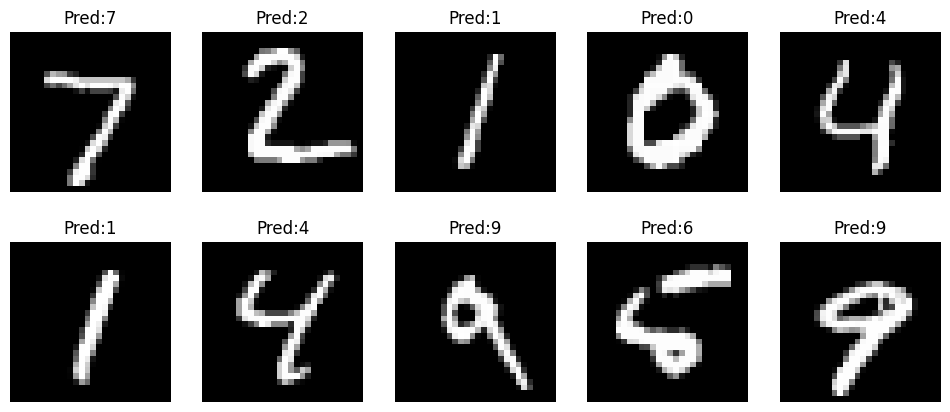

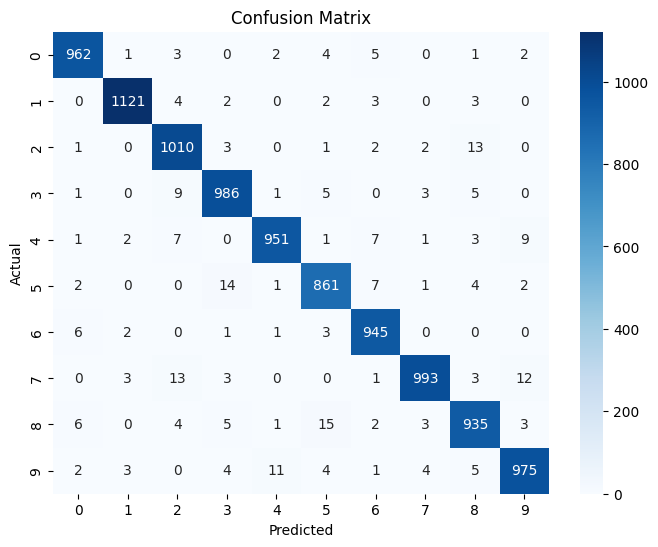


Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.96      0.97      0.96       892
           6       0.97      0.99      0.98       958
           7       0.99      0.97      0.98      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [1]:
#Handwritten Digit Identification and Prediction Using Artificial Neural Network (ANN)
# Step 1 : Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Step 2 : Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

# Step 3 : Normalize Images

X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 4 : Create Neural Network

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 5 : Compile Model

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6 : Train Model

history = model.fit(X_train,
                    y_train,
                    epochs=10,
                    validation_split=0.2)

# Step 7 : Evaluate

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy = {:.2f}%".format(accuracy*100))

# Step 8 : Predict

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Step 9 : Show Prediction Results

print("\nFirst 10 Predictions\n")

for i in range(10):
    print("Image", i+1,
          " Predicted =", predicted_classes[i],
          " Actual =", y_test[i])

# Step 10 : Display Sample Images

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Pred:"+str(predicted_classes[i]))
    plt.axis('off')

plt.show()

# Step 11 : Confusion Matrix

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 12 : Classification Report

print("\nClassification Report\n")

print(classification_report(y_test, predicted_classes))